# Analysis of Person Money Events


In [84]:
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import geopandas as gpd

policy_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-policy-10pct-deparking-p1_d0_i0_max1000_noLastCharging"

money_events = pd.read_csv("%s/berlin-v6.4.output_personMoneyEvents.tsv.gz" % policy_path, sep=";")
money_events["amount"] = money_events["amount"]* (-1)

persons = pd.read_csv("%s/berlin-v6.4.output_persons.csv.zst" % policy_path, sep=";", low_memory=False)

bezirke = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/bezirksgrenzen.geojson")
bezirke = bezirke.to_crs(epsg=3857)

umweltzone = gpd.read_file('../../../../input/v6.4/umweltzone/Umweltzone_Berlin.shp')
umweltzone = umweltzone.to_crs(epsg=3857)


In [85]:
sum(money_events["amount"])

6059.341937954972

In [86]:
money_events.columns

Index(['time', 'person', 'amount', 'purpose', 'transactionPartner',
       'reference'],
      dtype='str')

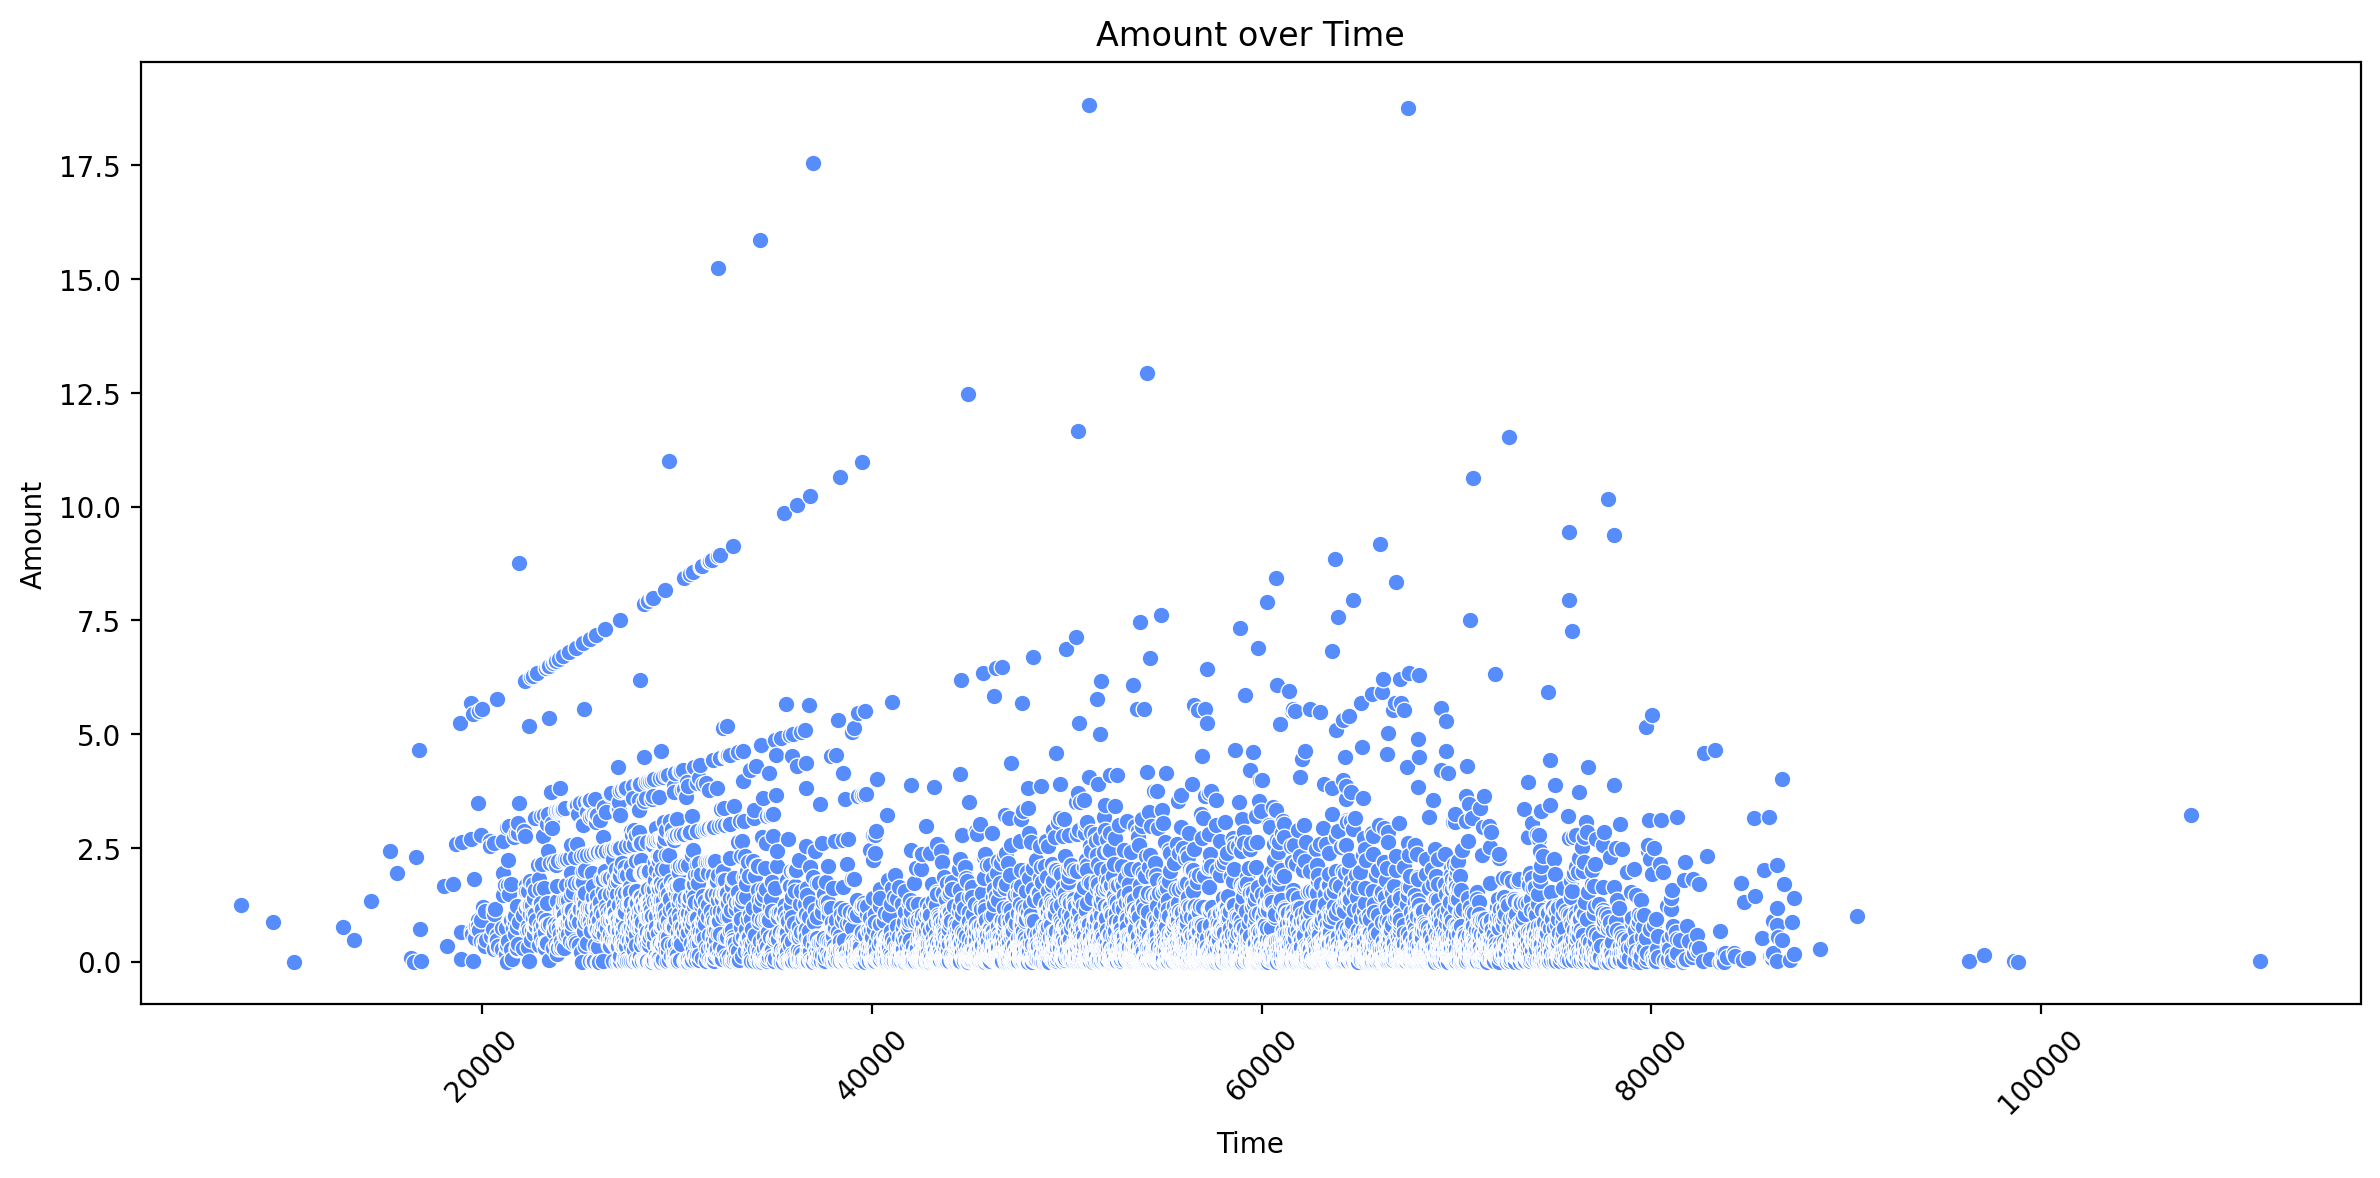

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt


# scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=money_events, x="time", y="amount")

plt.xlabel("Time")
plt.ylabel("Amount")
plt.title("Amount over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

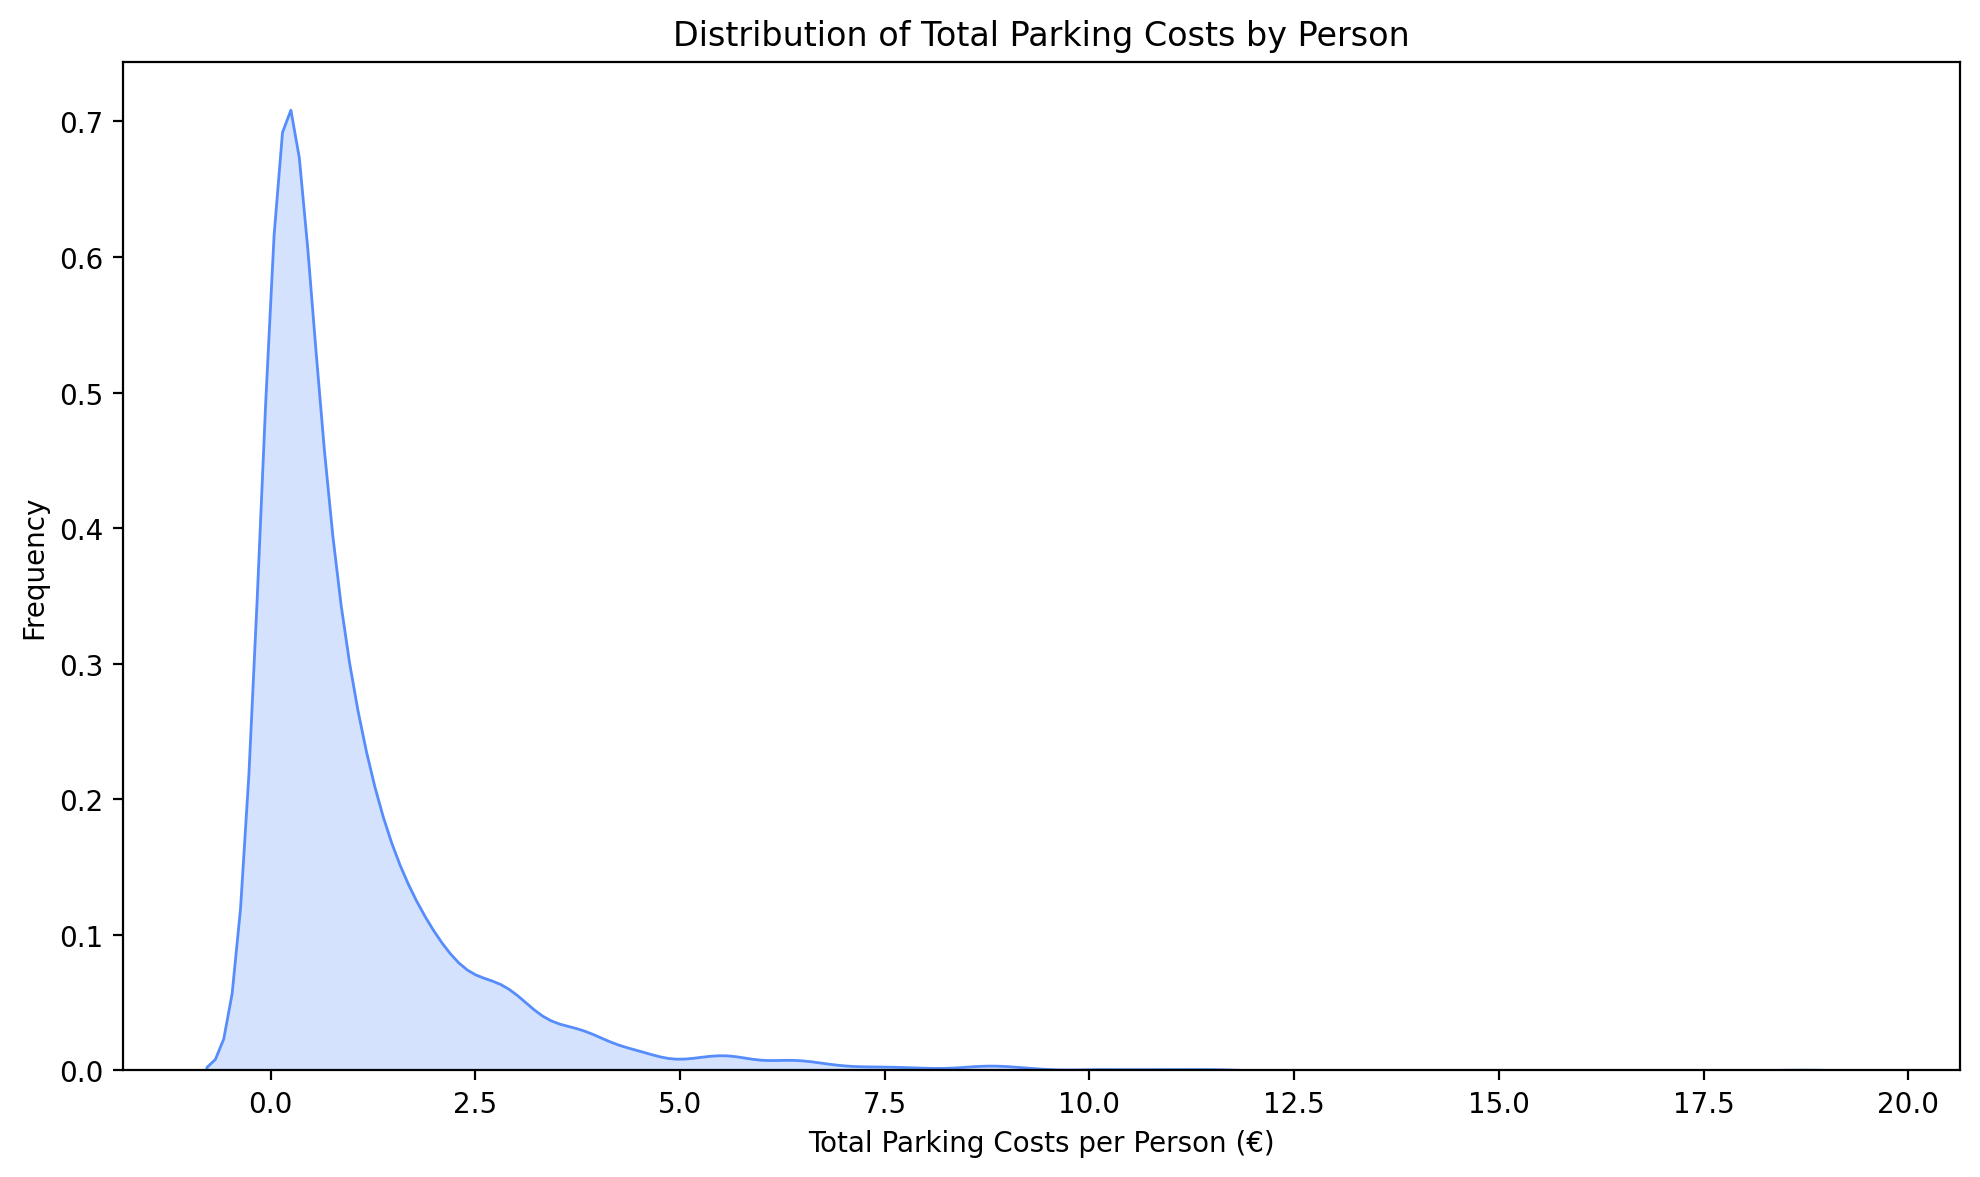

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# group by person and sum amounts
person_totals = (
    money_events.groupby("person")["amount"]
    .sum()
    .reset_index()
)

# distribution plot
plt.figure(figsize=(10, 6))

sns.kdeplot(person_totals["amount"], fill=True)

plt.xlabel("Total Parking Costs per Person (€)")
plt.ylabel("Frequency")
title = "Distribution of Total Parking Costs by Person"
plt.title(title)

plt.tight_layout()
plt.savefig("./plots/" + title + ".pdf", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()

In [30]:
# persons_total:
# contains aggregated money data per person

# persons:
# contains demographic / metadata columns

# merge on person
person_extended = person_totals.merge(
    persons,
    on="person",
    how="left"   # retain all rows from persons_total
)

# inspect result
person_extended.head()

,person,amount,executed_score,first_act_x,first_act_y,first_act_type,RegioStaR7,age,ars,bikeAvail,...,sex,subpopulation,ref_id,ref_modes,ref_weight,lor,zone,purpose,tourStartArea,vehicleTypes
0,bb_001ed1b0,0.599449,107.689003,780495.17,5831978.65,home_86400,3.0,34.0,1.206301e+11,always,...,m,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bb_00457d87,0.303897,133.595255,809510.71,5840915.33,home_86400,3.0,66.0,1.206000e+11,always,...,m,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bb_00ca7478,0.012762,135.279248,770312.09,5833342.22,home_86400,3.0,68.0,1.206300e+11,always,...,m,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bb_00d81fce,0.198772,57.260323,818468.65,5824317.10,home_86400,3.0,52.0,1.206704e+11,always,...,m,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bb_00eb4d34,0.056427,11.169295,844066.74,5803704.59,home_86400,7.0,53.0,1.206757e+11,never,...,m,person,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


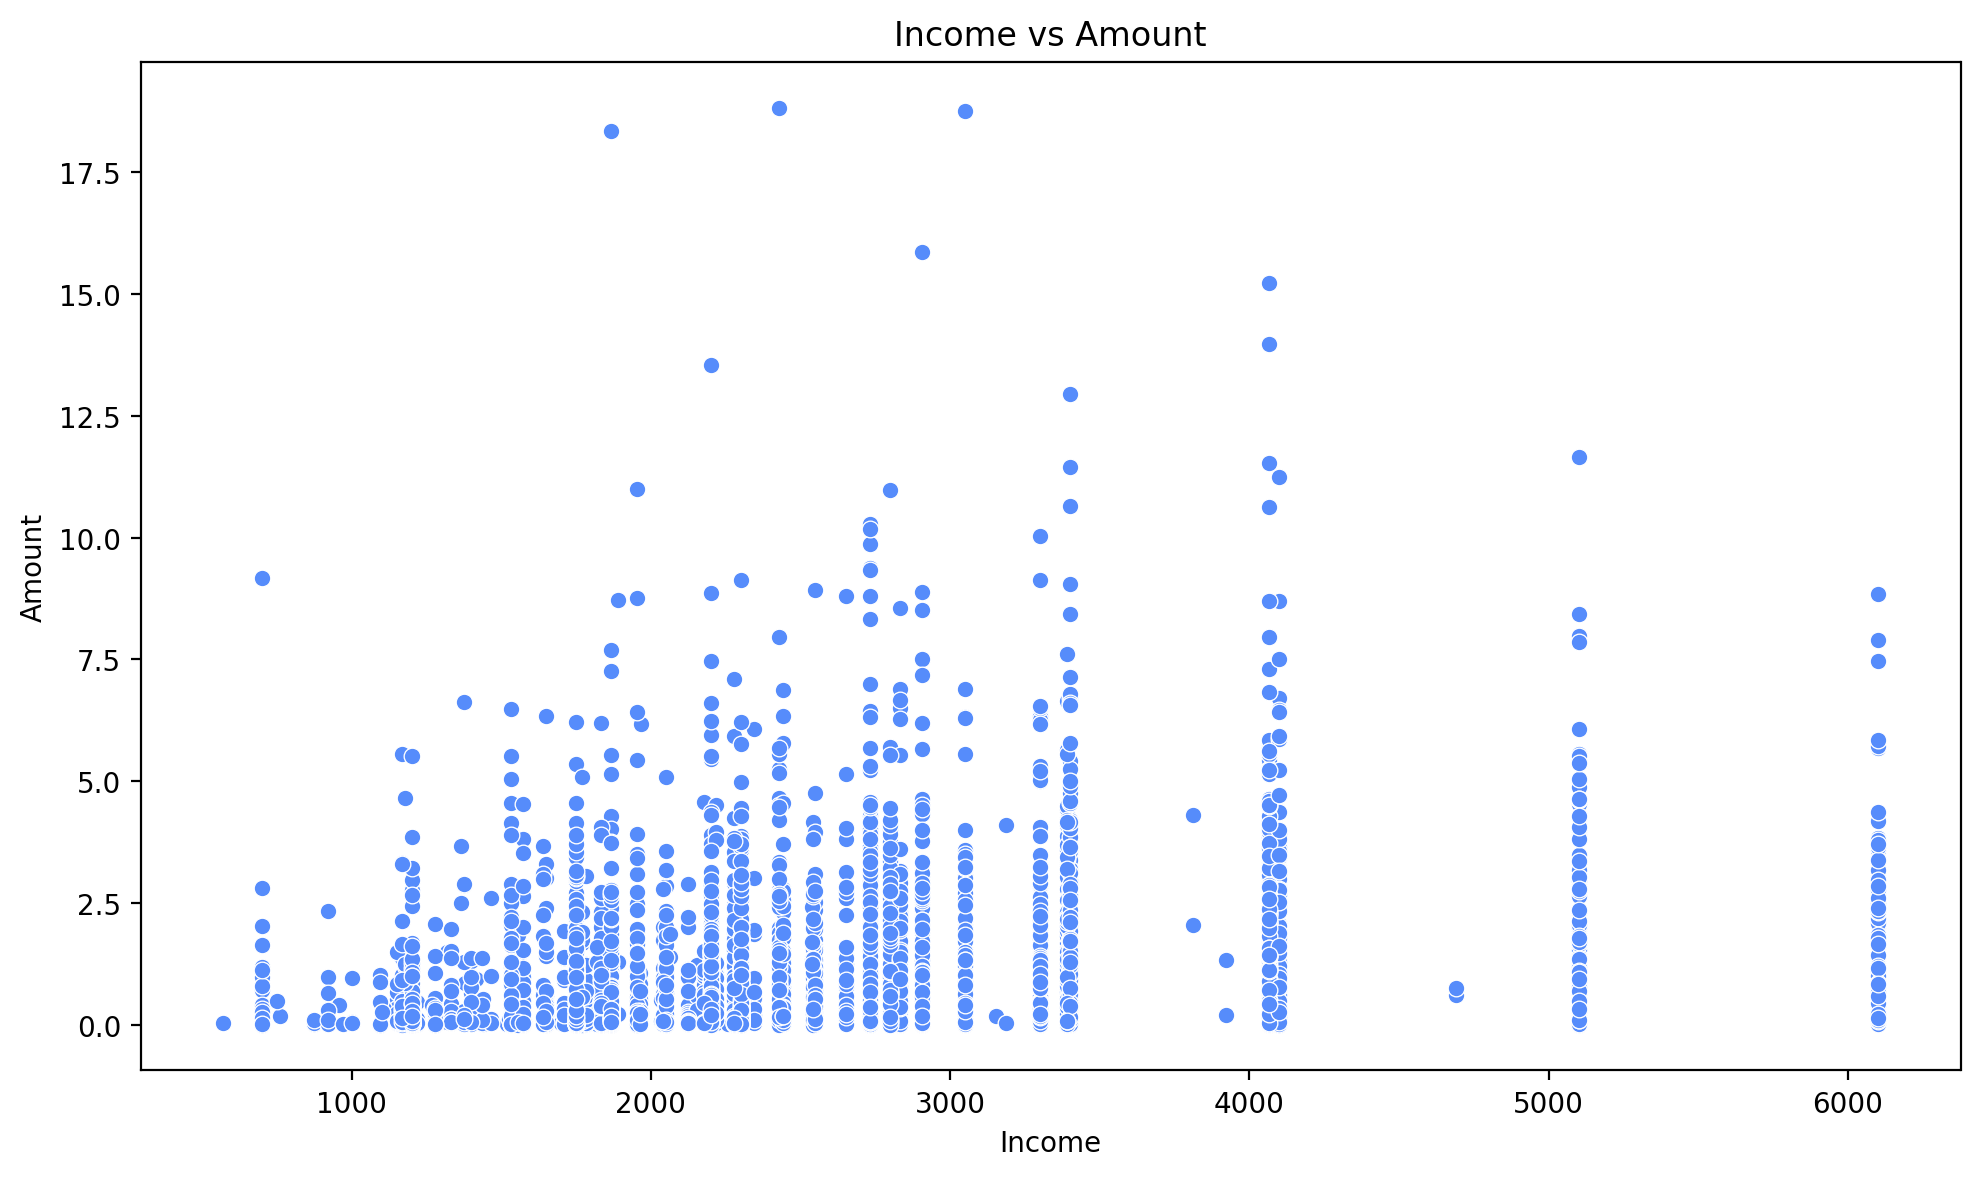

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=person_extended,
    x="income",
    y="amount"
)

plt.xlabel("Income")
plt.ylabel("Amount")
plt.title("Income vs Amount")

plt.tight_layout()
plt.show()

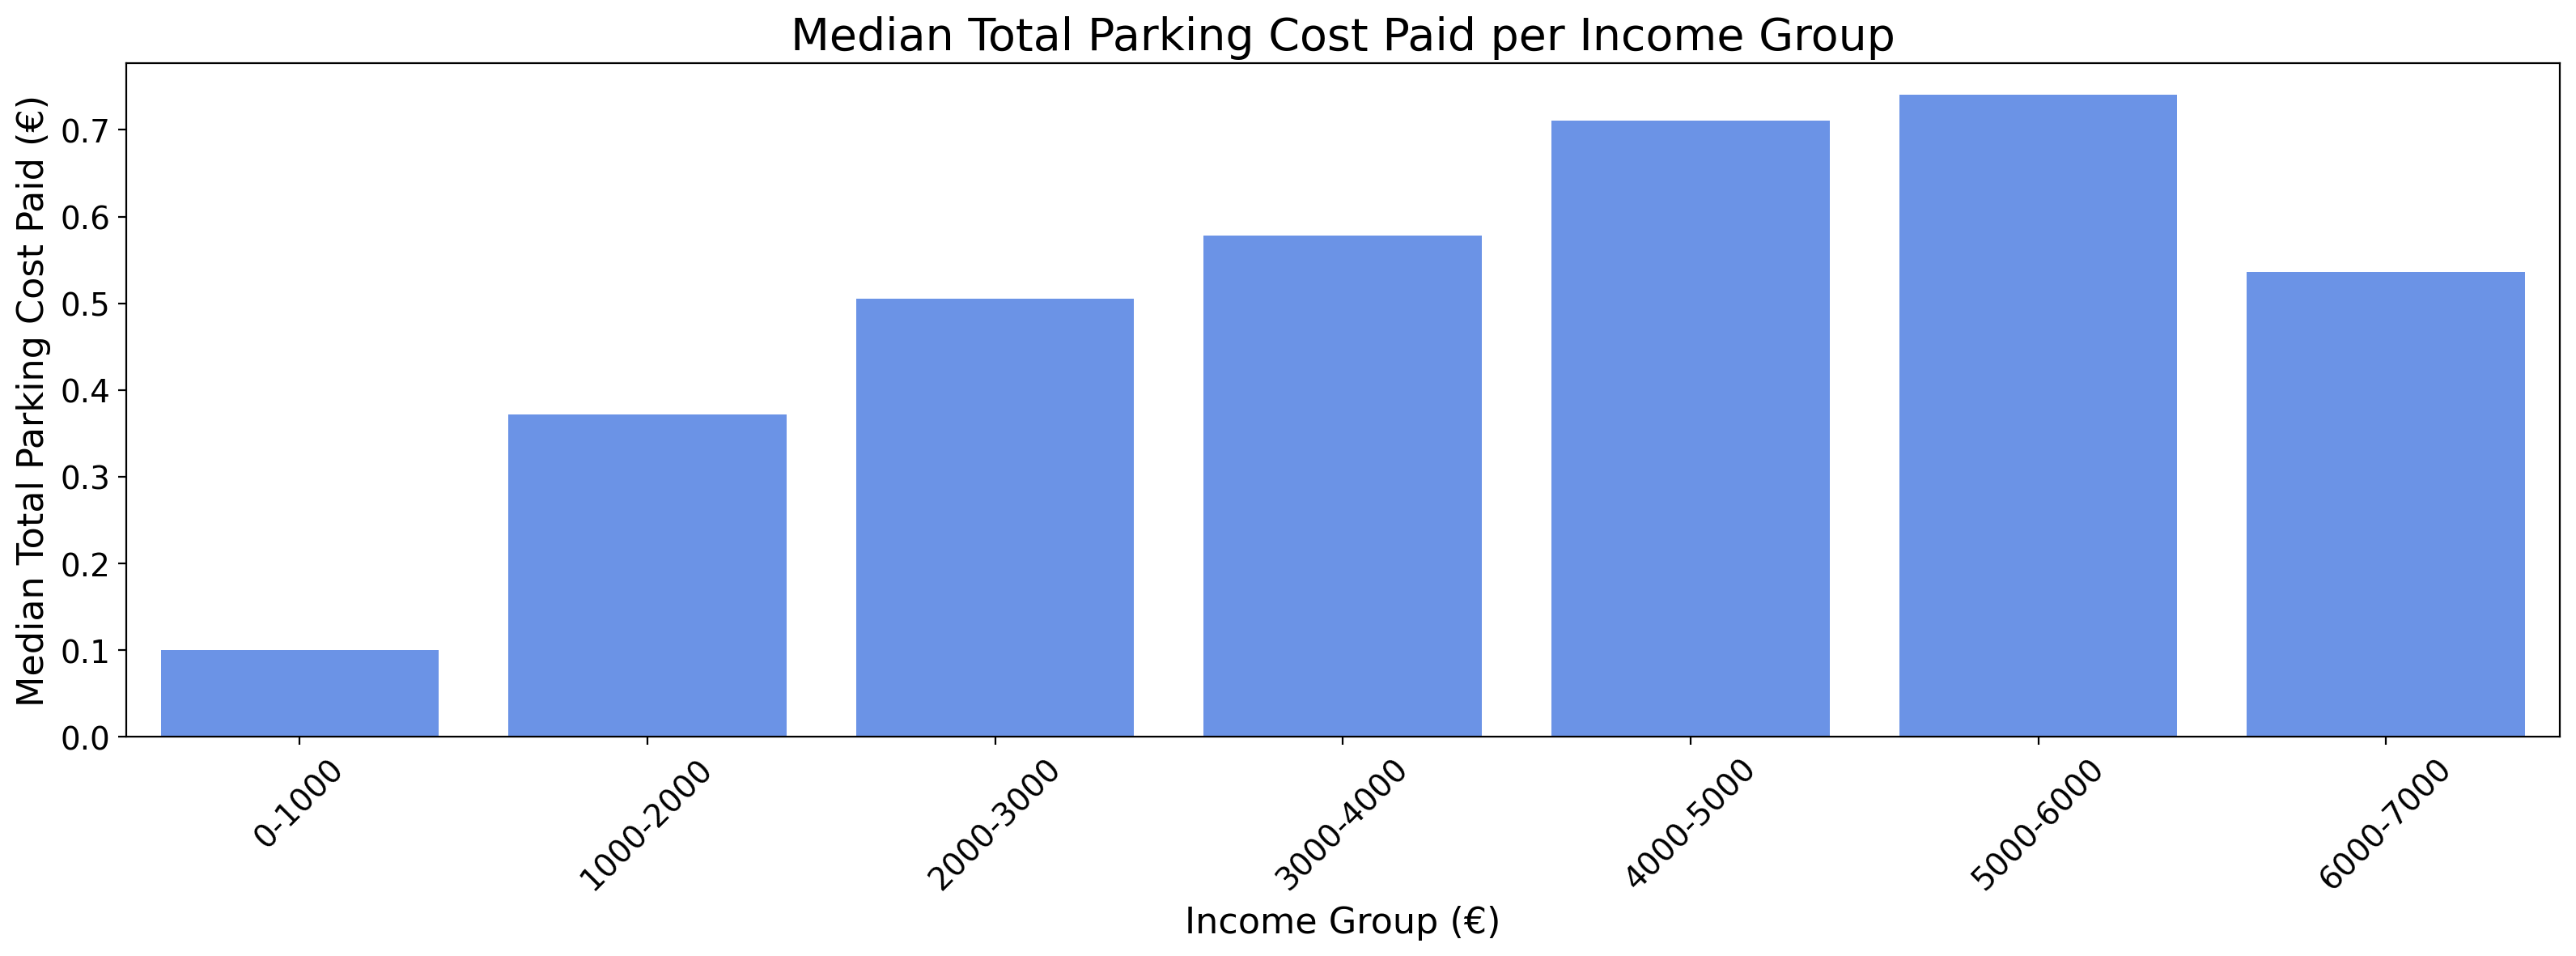

In [96]:
# define income bins
import numpy as np
max_income = person_extended["income"].max()
bins = np.arange(0, max_income + 1000, 1000)
labels = [
    f"{int(bins[i])}-{int(bins[i+1])}"
    for i in range(len(bins) - 1)
]

# create income groups
person_extended["income_bin"] = pd.cut(
    person_extended["income"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# median amount per income group
median_by_income = (
    person_extended
    .groupby("income_bin")["amount"]
    .median()
    .reset_index()
)

plt.figure(figsize=(16, 6))

sns.barplot(
    data=median_by_income,
    x="income_bin",
    y="amount"
)

title = "Median Total Parking Cost Paid per Income Group"
# title + labels
plt.title(
    title,
    fontsize=20
)

plt.xlabel(
    "Income Group (€)",
    fontsize=16
)

plt.ylabel(
    "Median Total Parking Cost Paid (€)",
    fontsize=16
)

# tick label sizes
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# legend size (only needed if legend exists)
# plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig("./plots/" + title + ".pdf", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()

<Axes: xlabel='income', ylabel='Count'>

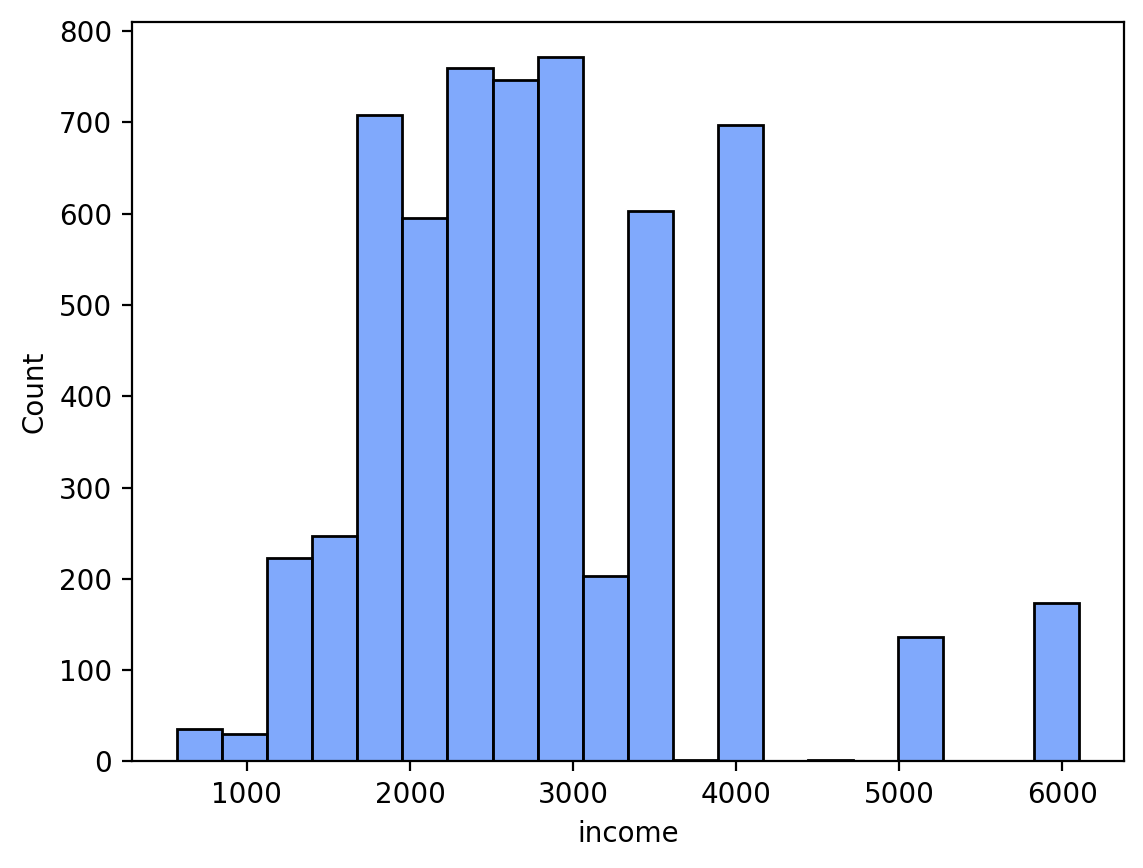

In [94]:
sns.histplot(person_extended, x= "income", bins=20)

In [37]:
person_extended.columns

Index(['person', 'amount', 'executed_score', 'first_act_x', 'first_act_y',
       'first_act_type', 'RegioStaR7', 'age', 'ars', 'bikeAvail', 'carAvail',
       'economic_status', 'employed', 'employment', 'gem', 'hasLicense',
       'home_x', 'home_y', 'household_equivalent_size', 'household_size',
       'household_type', 'income', 'marginalUtilityOfMoney', 'ptAboAvail',
       'restricted_mobility', 'sex', 'subpopulation', 'ref_id', 'ref_modes',
       'ref_weight', 'lor', 'zone', 'purpose', 'tourStartArea', 'vehicleTypes',
       'income_bin'],
      dtype='str')

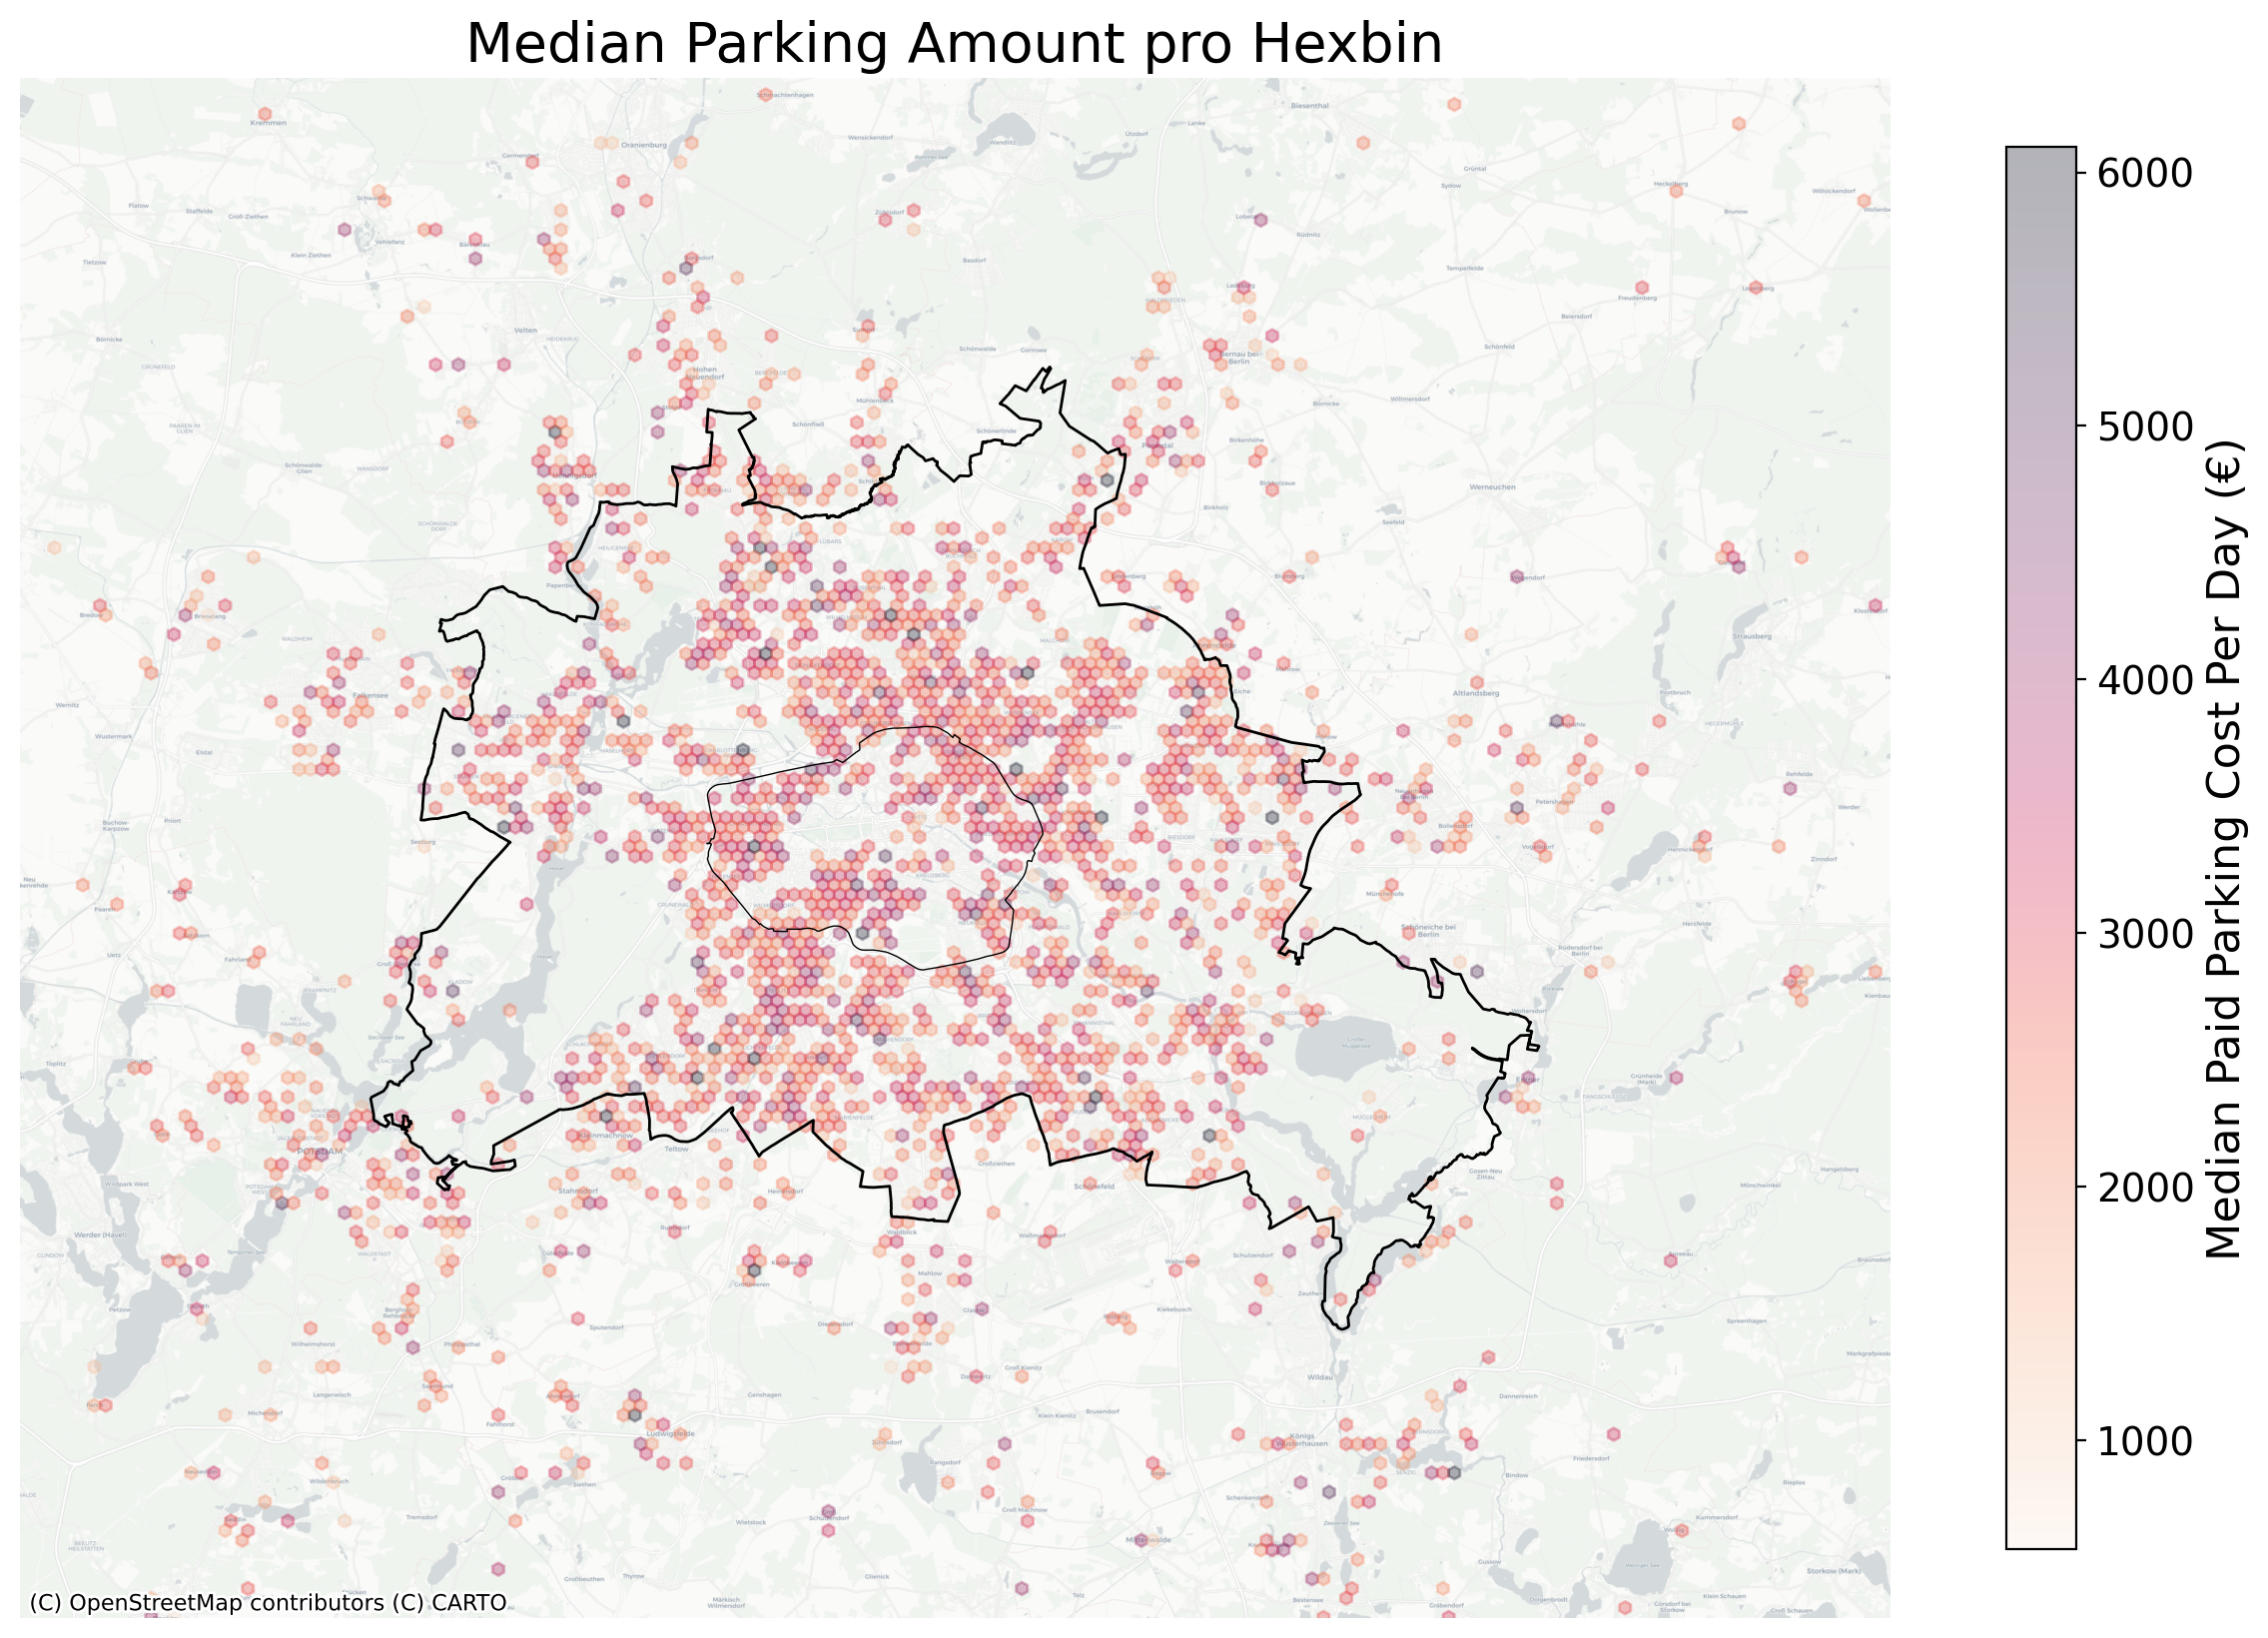

In [82]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# employee_extended = person_extended[person_extended["employed"]==True]

# GeoDataFrame erzeugen
gdf = gpd.GeoDataFrame(
    person_extended.copy(),
    geometry=gpd.points_from_xy(
        person_extended["home_x"],
        person_extended["home_y"]
    ),
    crs="EPSG:25832"
)

# Für contextily nach Web Mercator projizieren
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))

# Hexbin-Plot
hb = ax.hexbin(
    gdf_web.geometry.x,
    gdf_web.geometry.y,
    C=gdf_web["amount"],
    reduce_C_function=np.median,
    gridsize=500,
    cmap="rocket_r",
    mincnt=1,
    alpha=0.3,
)

# alle Bezirke zu einer Geometrie verschmelzen
bezirke_outline = bezirke.union_all()

# nur äußere Grenze plotten
gpd.GeoSeries(bezirke_outline.boundary, crs=bezirke.crs).plot(
    ax=ax,
    color="black",
    linewidth=1
)

umweltzone.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5
)

cbar.ax.tick_params(labelsize=14)

ax.set_aspect("equal", adjustable="box")

# Basemap hinzufügen
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    # source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=12
)

# Colorbar
cbar = fig.colorbar(hb, ax=ax, shrink=0.6)
cbar.set_label("Median Paid Parking Cost Per Day (€)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Titel + Achsen
ax.set_title(
    "Median Parking Amount pro Hexbin",
    fontsize=20
)

# Tick-Größen
ax.tick_params(axis="both", labelsize=14)

minx, miny, maxx, maxy = bezirke.total_bounds

x_diff = maxx - minx
y_diff = maxy - miny

buffer_factor = 0.3

minx -= x_diff * buffer_factor
maxx += x_diff * buffer_factor
miny -= y_diff * buffer_factor
maxy += y_diff * buffer_factor

ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])

# optional: Achsen schöner
ax.set_axis_off()

plt.tight_layout()
plt.show()